# NACA 4-Digit Geometry Explorer

This notebook walks through the `naca_4digit` generator step by step — showing intermediate arrays, key geometry quantities, and profiles for a range of design parameters.

**Kernel:** ApexFlow (Python 3.13) — select from *Kernel → Change Kernel* if not already active.

In [1]:
import sys
sys.path.insert(0, '..')   # repo root

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from mcp_server.naca_geometry import naca_4digit

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Cosine spacing — why it matters

A uniform grid of chord positions would under-resolve the leading and trailing edges where curvature is highest. Cosine spacing compresses points toward both ends:

$$x_c = \frac{1 - \cos(\beta)}{2}, \quad \beta \in [0, \pi]$$

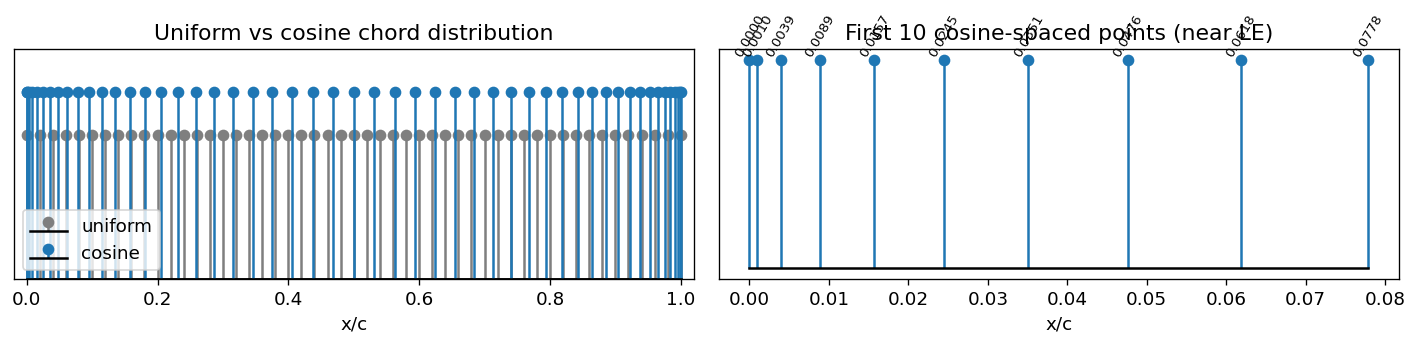

xc shape: (51,)   first 5: [0.      0.00099 0.00394 0.00886 0.01571]   last 5: [0.98429 0.99114 0.99606 0.99901 1.     ]


In [2]:
half = 50  # half of n_points for illustration
beta = np.linspace(0, np.pi, half + 1)   # (half+1,)
xc   = 0.5 * (1 - np.cos(beta))          # (half+1,)  — chord positions LE→TE

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].stem(np.linspace(0, 1, half + 1), np.ones(half + 1),
             linefmt='C7-', markerfmt='C7o', basefmt='k-', label='uniform')
axes[0].stem(xc, np.ones(half + 1) * 1.3,
             linefmt='C0-', markerfmt='C0o', basefmt='k-', label='cosine')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(0, 1.6)
axes[0].set_xlabel('x/c')
axes[0].set_title('Uniform vs cosine chord distribution')
axes[0].legend()
axes[0].set_yticks([])

# Zoom near leading edge
axes[1].stem(xc[:10], np.ones(10),
             linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[1].set_xlabel('x/c')
axes[1].set_title('First 10 cosine-spaced points (near LE)')
axes[1].set_yticks([])
for i, x in enumerate(xc[:10]):
    axes[1].annotate(f'{x:.4f}', (x, 1.02), ha='center', fontsize=8, rotation=60)

plt.tight_layout()
plt.show()

print(f"xc shape: {xc.shape}   first 5: {xc[:5].round(5)}   last 5: {xc[-5:].round(5)}")

---
## 2. Thickness distribution  yt(x)

The NACA half-thickness at each chord position:

$$y_t(x) = 5t \left( 0.2969\sqrt{x} - 0.1260\,x - 0.3516\,x^2 + 0.2843\,x^3 - a_4\,x^4 \right)$$

with $a_4 = 0.1036$ (`closed_te=True`) to force $y_t(1)=0$, or $a_4 = 0.1015$ (standard).

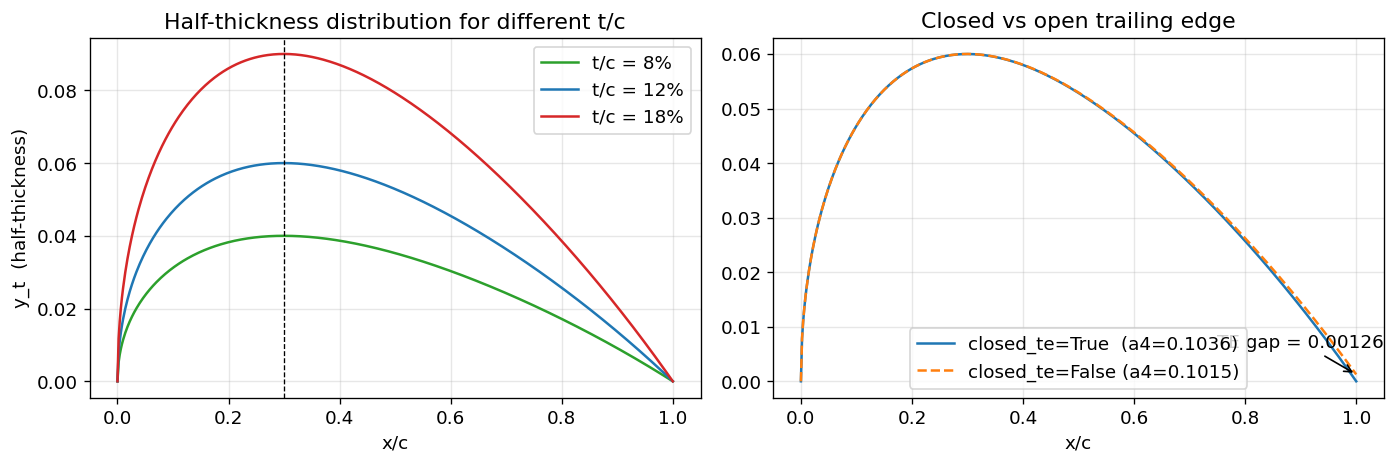

Max yt = 0.0600  at x/c = 0.299
yt(1) closed = -1.67e-17   yt(1) open = 0.00126


In [3]:
t = 0.12
xc_fine = np.linspace(0, 1, 500)

def yt_fn(x, t, closed_te=True):
    a4 = 0.1036 if closed_te else 0.1015
    return 5 * t * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - a4*x**4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: yt for three thickness ratios
for ti, col in zip([0.08, 0.12, 0.18], ['C2', 'C0', 'C3']):
    axes[0].plot(xc_fine, yt_fn(xc_fine, ti), color=col, label=f't/c = {ti:.0%}')
axes[0].set_xlabel('x/c')
axes[0].set_ylabel('y_t  (half-thickness)')
axes[0].set_title('Half-thickness distribution for different t/c')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axvline(0.3, color='k', ls='--', lw=0.8, label='x=0.30')

# Right: closed vs open TE
yt_closed = yt_fn(xc_fine, t, closed_te=True)
yt_open   = yt_fn(xc_fine, t, closed_te=False)
axes[1].plot(xc_fine, yt_closed, 'C0-', label='closed_te=True  (a4=0.1036)')
axes[1].plot(xc_fine, yt_open,   'C1--', label='closed_te=False (a4=0.1015)')
axes[1].set_xlabel('x/c')
axes[1].set_title('Closed vs open trailing edge')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Annotate TE gap
te_gap = yt_fn(1.0, t, closed_te=False)
axes[1].annotate(f'TE gap = {te_gap:.5f}', xy=(1.0, te_gap),
                 xytext=(0.75, te_gap + 0.005), arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

idx_max = np.argmax(yt_fn(xc_fine, t))
print(f"Max yt = {yt_fn(xc_fine, t)[idx_max]:.4f}  at x/c = {xc_fine[idx_max]:.3f}")
print(f"yt(1) closed = {yt_fn(1.0, t, True):.2e}   yt(1) open = {yt_fn(1.0, t, False):.5f}")

---
## 3. Camber line  yc(x)  and slope  dyc/dx

The camber line is piecewise-parabolic:

$$y_c = \begin{cases} \frac{m}{p^2}(2px - x^2) & x \le p \\ \frac{m}{(1-p)^2}\bigl((1-2p)+2px-x^2\bigr) & x > p \end{cases}$$

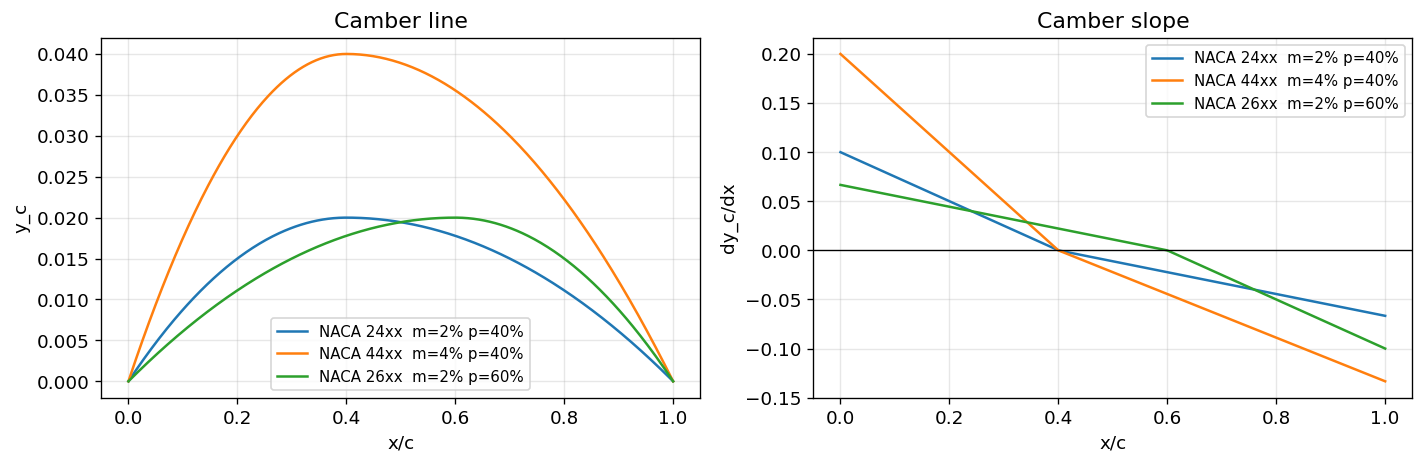

In [4]:
def camber_fn(x, m, p):
    if m == 0:
        return np.zeros_like(x), np.zeros_like(x)
    fore = x <= p
    yc  = np.where(fore,
                   (m/p**2)*(2*p*x - x**2),
                   (m/(1-p)**2)*((1-2*p) + 2*p*x - x**2))
    dyc = np.where(fore,
                   (2*m/p**2)*(p - x),
                   (2*m/(1-p)**2)*(p - x))
    return yc, dyc

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

configs = [(0.02, 0.4, 'NACA 24xx  m=2% p=40%'),
           (0.04, 0.4, 'NACA 44xx  m=4% p=40%'),
           (0.02, 0.6, 'NACA 26xx  m=2% p=60%')]

for m, p, label in configs:
    yc, dyc = camber_fn(xc_fine, m, p)
    axes[0].plot(xc_fine, yc,  label=label)
    axes[1].plot(xc_fine, dyc, label=label)

axes[0].set_xlabel('x/c');  axes[0].set_ylabel('y_c')
axes[0].set_title('Camber line');  axes[0].legend(fontsize=9);  axes[0].grid(alpha=0.3)
axes[1].set_xlabel('x/c');  axes[1].set_ylabel('dy_c/dx')
axes[1].set_title('Camber slope');  axes[1].legend(fontsize=9);  axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='k', lw=0.8)

plt.tight_layout()
plt.show()

---
## 4. Building the surface — step by step

Starting from the camber line and thickness, the surface coordinates are:

$$x_{u/l} = x_c \mp y_t \sin\theta, \quad y_{u/l} = y_c \pm y_t \cos\theta, \quad \theta = \arctan\!\left(\frac{dy_c}{dx}\right)$$

In [5]:
# Work through NACA 2412 step by step
m, p, t = 0.02, 0.4, 0.12
n_pts   = 200
half    = n_pts // 2

beta = np.linspace(0, np.pi, half + 1)    # (half+1,) = (101,)
xc   = 0.5 * (1 - np.cos(beta))           # (101,)  LE→TE

# Thickness
yt = 5*t*(0.2969*np.sqrt(xc) - 0.1260*xc - 0.3516*xc**2 + 0.2843*xc**3 - 0.1036*xc**4)  # (101,)

# Camber
yc, dyc = camber_fn(xc, m, p)             # (101,), (101,)
theta   = np.arctan(dyc)                   # (101,)

# Surface points (all in LE→TE chord order)
xu = xc - yt * np.sin(theta)              # (101,)
yu = yc + yt * np.cos(theta)              # (101,)
xl = xc + yt * np.sin(theta)              # (101,)
yl = yc - yt * np.cos(theta)              # (101,)

# Assembly: CCW from TE — drop LE to avoid duplicate
upper = np.column_stack([xu[::-1][:-1], yu[::-1][:-1]])   # (half, 2) = (100, 2)  TE→near-LE
lower = np.column_stack([xl[1:],        yl[1:]])           # (half, 2) = (100, 2)  near-LE→TE
coords = np.vstack([upper, lower])                         # (n_pts, 2) = (200, 2)

print(f"beta  shape: {beta.shape}")
print(f"xc    shape: {xc.shape}   range [{xc[0]:.4f}, {xc[-1]:.4f}]")
print(f"yt    shape: {yt.shape}   range [{yt.min():.4f}, {yt.max():.4f}]")
print(f"yc    shape: {yc.shape}   range [{yc.min():.4f}, {yc.max():.4f}]")
print(f"theta shape: {theta.shape} range [{np.degrees(theta.min()):.2f}°, {np.degrees(theta.max()):.2f}°]")
print(f"upper shape: {upper.shape}")
print(f"lower shape: {lower.shape}")
print(f"coords shape: {coords.shape}")
print(f"TE gap: {np.linalg.norm(coords[0] - coords[-1]):.2e}")

beta  shape: (101,)
xc    shape: (101,)   range [0.0000, 1.0000]
yt    shape: (101,)   range [-0.0000, 0.0600]
yc    shape: (101,)   range [0.0000, 0.0200]
theta shape: (101,) range [-3.81°, 5.71°]
upper shape: (100, 2)
lower shape: (100, 2)
coords shape: (200, 2)
TE gap: 3.32e-17


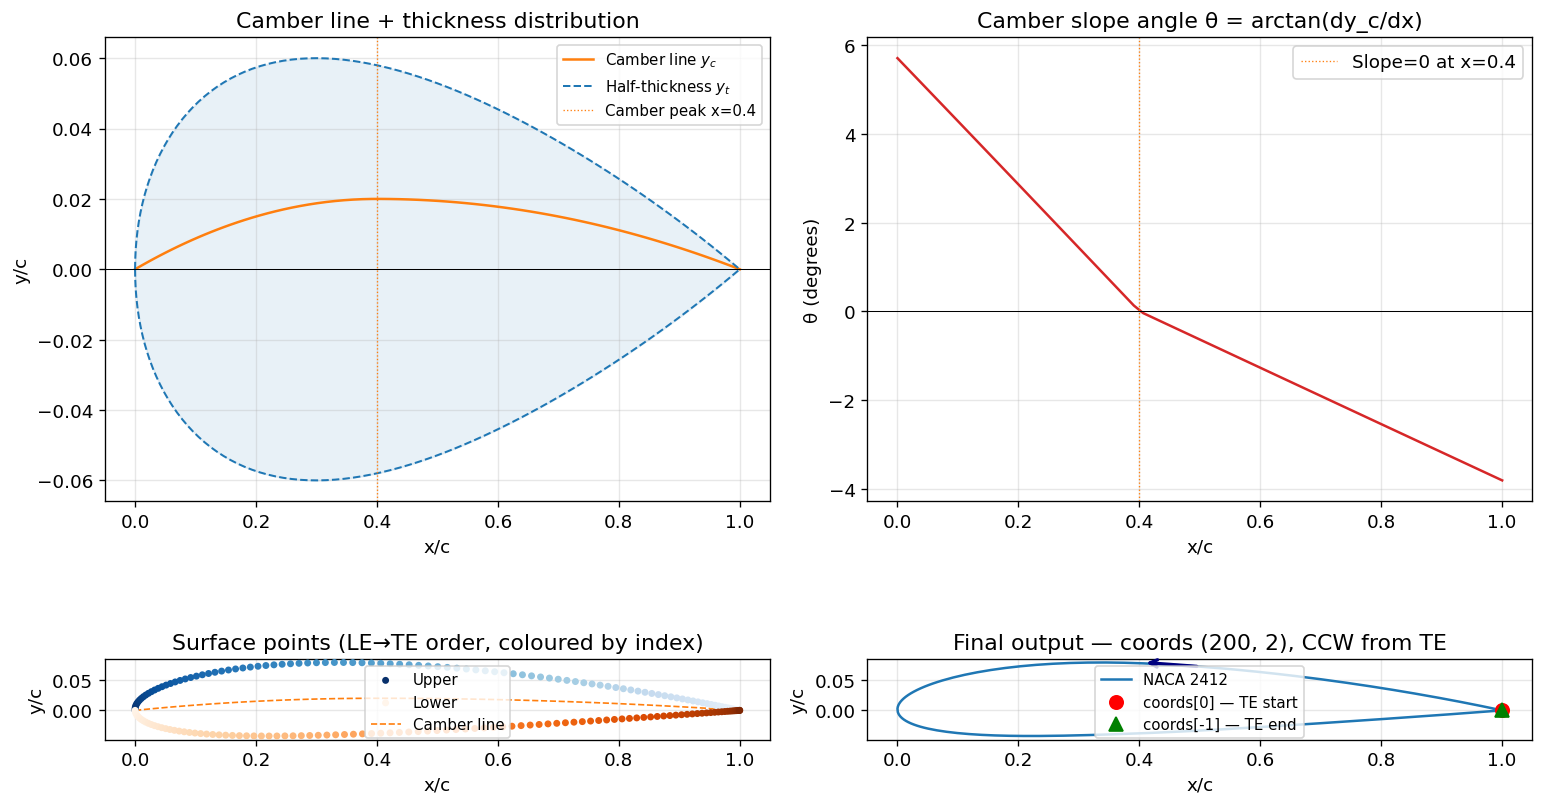

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1: Camber + thickness decomposition
ax = axes[0, 0]
ax.plot(xc, yc,  'C1-',  lw=1.5, label='Camber line $y_c$')
ax.plot(xc, yt,  'C0--', lw=1.2, label='Half-thickness $y_t$')
ax.plot(xc, -yt, 'C0--', lw=1.2)
ax.fill_between(xc, yt, -yt, alpha=0.1, color='C0')
ax.axhline(0, color='k', lw=0.6)
ax.axvline(p, color='C1', ls=':', lw=0.8, label=f'Camber peak x={p}')
ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title('Camber line + thickness distribution')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

# Panel 2: θ (camber rotation angle)
ax = axes[0, 1]
ax.plot(xc, np.degrees(theta), 'C3-')
ax.axhline(0, color='k', lw=0.6)
ax.axvline(p, color='C1', ls=':', lw=0.8, label=f'Slope=0 at x={p}')
ax.set_xlabel('x/c');  ax.set_ylabel('θ (degrees)')
ax.set_title('Camber slope angle θ = arctan(dy_c/dx)')
ax.legend();  ax.grid(alpha=0.3)

# Panel 3: Surface coordinates coloured by surface index
ax = axes[1, 0]
ax.scatter(xu, yu, c=np.arange(len(xc)), cmap='Blues_r', s=10, label='Upper', zorder=3)
ax.scatter(xl, yl, c=np.arange(len(xc)), cmap='Oranges',  s=10, label='Lower', zorder=3)
ax.plot(xc, yc, 'C1--', lw=1, label='Camber line')
ax.set_aspect('equal');  ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title('Surface points (LE→TE order, coloured by index)')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

# Panel 4: Final assembled coords with CCW arrow
ax = axes[1, 1]
ax.plot(coords[:, 0], coords[:, 1], 'C0-', lw=1.5, label='NACA 2412')
ax.plot(coords[0, 0], coords[0, 1], 'ro', ms=8, label='coords[0] — TE start')
ax.plot(coords[-1, 0], coords[-1, 1], 'g^', ms=8, label='coords[-1] — TE end')
# Arrow showing traversal direction
mid = len(coords) // 4
dx = coords[mid+1, 0] - coords[mid-1, 0]
dy = coords[mid+1, 1] - coords[mid-1, 1]
ax.annotate('', xy=(coords[mid,0]+dx*3, coords[mid,1]+dy*3),
            xytext=(coords[mid,0], coords[mid,1]),
            arrowprops=dict(arrowstyle='->', color='navy', lw=2))
ax.set_aspect('equal');  ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title('Final output — coords (200, 2), CCW from TE')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Gallery — varying angle of attack (rotation)

OpenFOAM applies AoA by rotating the *freestream velocity*, not the geometry. This cell shows what the geometry looks like at different chord-aligned orientations for intuition.

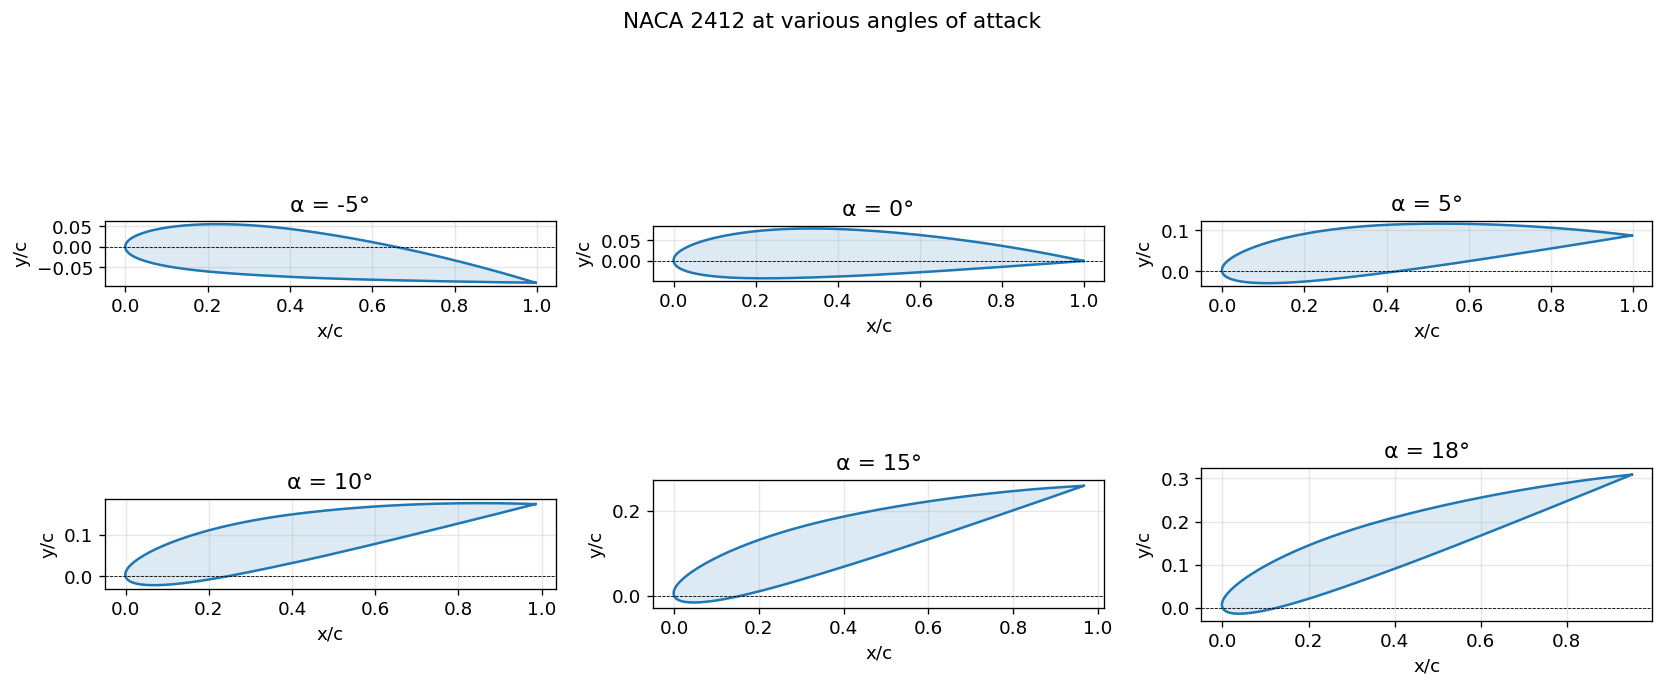

In [7]:
def rotate(coords, alpha_deg):
    """Rotate coordinates by alpha_deg (positive = nose-up)."""
    a = np.radians(alpha_deg)
    R = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a),  np.cos(a)]])
    return coords @ R.T

aoa_values = [-5, 0, 5, 10, 15, 18]
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=False, sharey=False)

base = naca_4digit(0.02, 0.4, 0.12, n_points=200)

for ax, alpha in zip(axes.flat, aoa_values):
    rotated = rotate(base, alpha)
    ax.plot(rotated[:, 0], rotated[:, 1], 'C0-', lw=1.5)
    ax.fill(rotated[:, 0], rotated[:, 1], alpha=0.15, color='C0')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_aspect('equal')
    ax.set_title(f'α = {alpha}°')
    ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
    ax.grid(alpha=0.3)

plt.suptitle('NACA 2412 at various angles of attack', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Gallery — design space profiles

A sweep across the four design parameters used in the ApexFlow sampling plan.

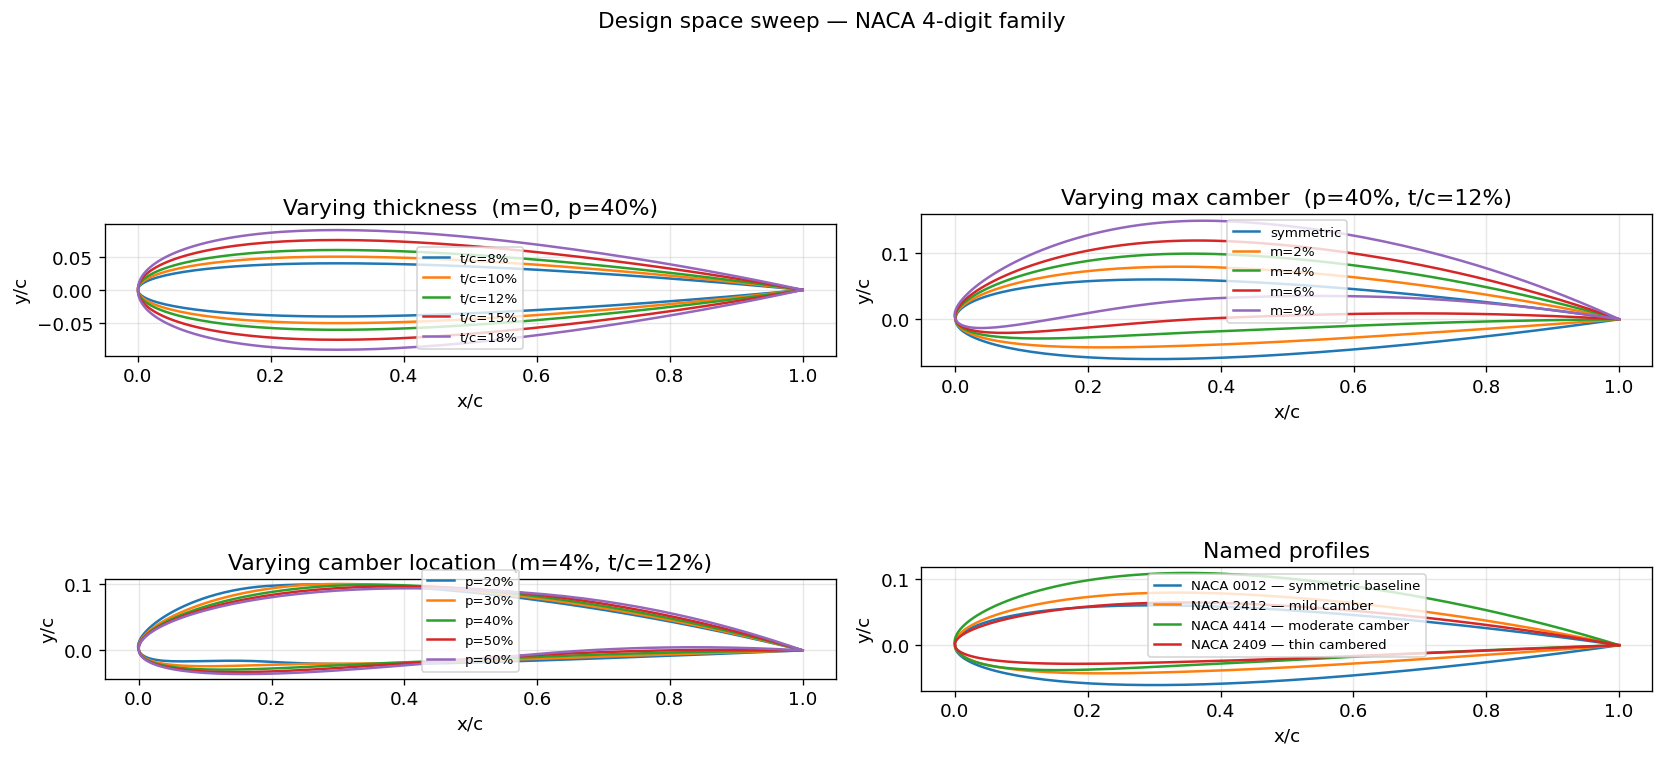

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# --- Vary thickness (t/c) ---
ax = axes[0, 0]
for t_val in [0.08, 0.10, 0.12, 0.15, 0.18]:
    c = naca_4digit(0, 0.4, t_val)
    ax.plot(c[:, 0], c[:, 1], label=f't/c={t_val:.0%}')
ax.set_aspect('equal');  ax.set_title('Varying thickness  (m=0, p=40%)')
ax.set_xlabel('x/c');  ax.set_ylabel('y/c');  ax.legend(fontsize=8);  ax.grid(alpha=0.3)

# --- Vary max camber (m) ---
ax = axes[0, 1]
for m_val in [0.0, 0.02, 0.04, 0.06, 0.09]:
    c = naca_4digit(m_val, 0.4, 0.12)
    label = f'm={m_val:.0%}' if m_val > 0 else 'symmetric'
    ax.plot(c[:, 0], c[:, 1], label=label)
ax.set_aspect('equal');  ax.set_title('Varying max camber  (p=40%, t/c=12%)')
ax.set_xlabel('x/c');  ax.set_ylabel('y/c');  ax.legend(fontsize=8);  ax.grid(alpha=0.3)

# --- Vary camber location (p) ---
ax = axes[1, 0]
for p_val in [0.2, 0.3, 0.4, 0.5, 0.6]:
    c = naca_4digit(0.04, p_val, 0.12)
    ax.plot(c[:, 0], c[:, 1], label=f'p={int(p_val*100)}%')
ax.set_aspect('equal');  ax.set_title('Varying camber location  (m=4%, t/c=12%)')
ax.set_xlabel('x/c');  ax.set_ylabel('y/c');  ax.legend(fontsize=8);  ax.grid(alpha=0.3)

# --- Named profiles used in F1/aerospace ---
ax = axes[1, 1]
named = [
    (0,    0.4, 0.12, 'NACA 0012 — symmetric baseline'),
    (0.02, 0.4, 0.12, 'NACA 2412 — mild camber'),
    (0.04, 0.4, 0.14, 'NACA 4414 — moderate camber'),
    (0.02, 0.4, 0.09, 'NACA 2409 — thin cambered'),
]
for m, p, t, label in named:
    c = naca_4digit(m, p, t)
    ax.plot(c[:, 0], c[:, 1], label=label)
ax.set_aspect('equal');  ax.set_title('Named profiles')
ax.set_xlabel('x/c');  ax.set_ylabel('y/c');  ax.legend(fontsize=8);  ax.grid(alpha=0.3)

plt.suptitle('Design space sweep — NACA 4-digit family', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Point-density inspection

Verify cosine spacing is working: segment lengths should be smallest near LE and TE.

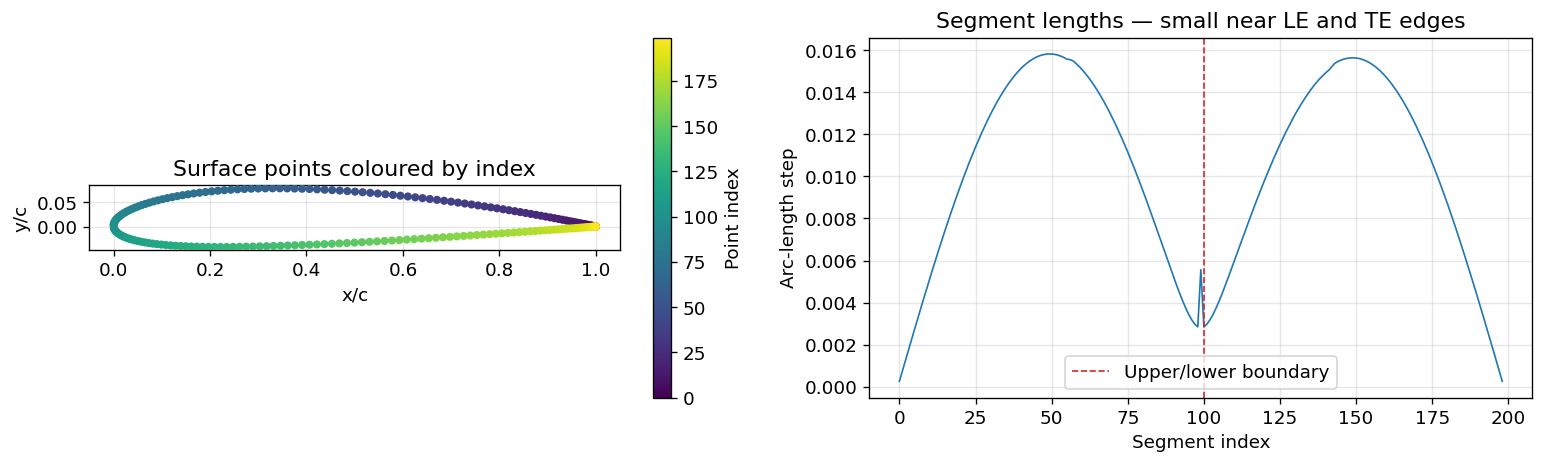

coords shape: (200, 2)
Segment lengths — min: 0.00025  max: 0.01583  ratio: 63.4x
TE gap (first–last): 3.32e-17


In [9]:
coords = naca_4digit(0.02, 0.4, 0.12, n_points=200)

# Segment lengths along the surface
seg_lengths = np.linalg.norm(np.diff(coords, axis=0), axis=1)   # (199,)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(coords[:, 0], coords[:, 1], 'C0-', lw=1)
sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=np.arange(200),
                     cmap='viridis', s=15, zorder=3)
plt.colorbar(sc, ax=axes[0], label='Point index')
axes[0].set_aspect('equal');  axes[0].set_title('Surface points coloured by index')
axes[0].set_xlabel('x/c');  axes[0].set_ylabel('y/c');  axes[0].grid(alpha=0.3)

axes[1].plot(seg_lengths, 'C0-', lw=1)
axes[1].axvline(100, color='C3', ls='--', lw=1, label='Upper/lower boundary')
axes[1].set_xlabel('Segment index');  axes[1].set_ylabel('Arc-length step')
axes[1].set_title('Segment lengths — small near LE and TE edges')
axes[1].legend();  axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"coords shape: {coords.shape}")
print(f"Segment lengths — min: {seg_lengths.min():.5f}  max: {seg_lengths.max():.5f}  "
      f"ratio: {seg_lengths.max()/seg_lengths.min():.1f}x")
print(f"TE gap (first–last): {np.linalg.norm(coords[0] - coords[-1]):.2e}")

---
## 8. Thin airfoil theory — sanity check

For small AoA, thin airfoil theory predicts $C_l \approx 2\pi\sin(\alpha)$. The geometry generator feeds the CFD pipeline, so here we verify the geometry is consistent with what the surrogate will later learn. The camber angle at the TE gives the zero-lift angle $\alpha_0$:

$$\alpha_0 \approx -\frac{1}{\pi}\int_0^1 \frac{dy_c}{dx}\left(\frac{1}{\sqrt{x(1-x)}}\right)dx$$

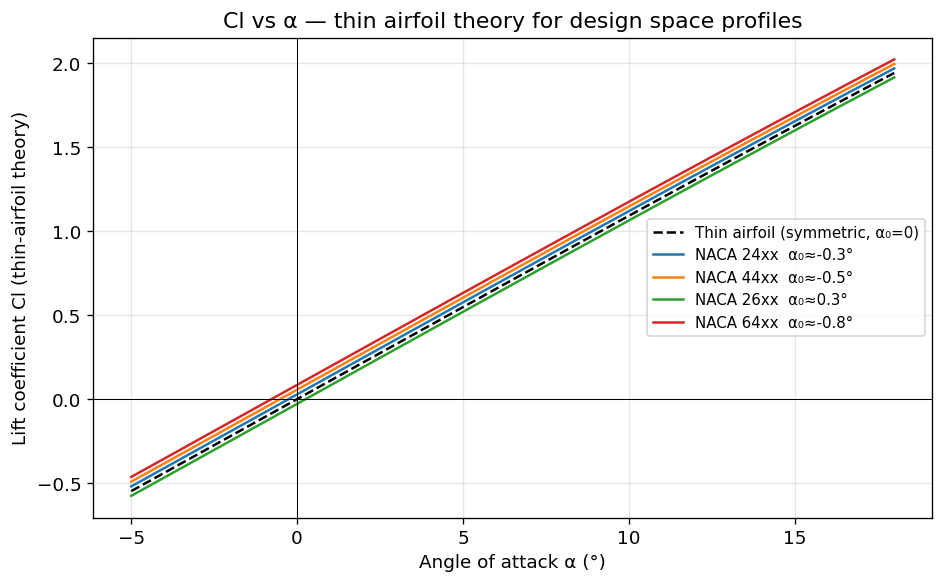

In [10]:
from scipy.integrate import quad

def zero_lift_angle_deg(m, p):
    """Thin airfoil theory zero-lift angle (degrees)."""
    if m == 0:
        return 0.0
    def integrand(x):
        if x <= p:
            dyc = (2*m/p**2)*(p - x)
        else:
            dyc = (2*m/(1-p)**2)*(p - x)
        return dyc / np.sqrt(max(x*(1-x), 1e-12))
    val, _ = quad(integrand, 0, 1, limit=200)
    return np.degrees(-val / np.pi)

alpha_range = np.linspace(-5, 18, 50)
Cl_theory   = 2 * np.pi * np.sin(np.radians(alpha_range))  # symmetric

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(alpha_range, Cl_theory, 'k--', lw=1.5, label='Thin airfoil (symmetric, α₀=0)')

colours = ['C0', 'C1', 'C2', 'C3']
for (m, p, label), col in zip(
        [(0.02, 0.4, 'NACA 24xx'), (0.04, 0.4, 'NACA 44xx'),
         (0.02, 0.6, 'NACA 26xx'), (0.06, 0.4, 'NACA 64xx')], colours):
    a0 = zero_lift_angle_deg(m, p)
    Cl = 2 * np.pi * np.sin(np.radians(alpha_range - a0))
    ax.plot(alpha_range, Cl, color=col, lw=1.5, label=f'{label}  α₀≈{a0:.1f}°')

ax.axhline(0, color='k', lw=0.6)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('Angle of attack α (°)')
ax.set_ylabel('Lift coefficient Cl (thin-airfoil theory)')
ax.set_title('Cl vs α — thin airfoil theory for design space profiles')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()